In [8]:
from galpy.df import isotropicPlummerdf
from galpy.potential import PlummerPotential, NFWPotential
from ezfalcon.simulation import Sim
from ezfalcon.util import galpydfsampler
import astropy.units as u


import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    'xtick.direction': 'in', 'ytick.direction': 'in',
    'font.size': 14, 'axes.labelsize': 16,
    'xtick.major.width': 1.5, 'ytick.major.width': 1.5,
    'ytick.right': True, 'xtick.top': True,
    'mathtext.fontset': 'stix',
    'xtick.minor.visible': True, 'ytick.minor.visible': True,
})

In [19]:
shell = Sim()

sat_pot = PlummerPotential(amp=1e9 * u.Msun, b=1*u.kpc)
df = isotropicPlummerdf(pot = sat_pot)
pos, vel, mass = galpydfsampler(df=df, n=1000, m_total=1e9, center_pos=[50, 0, 0], center_vel=[0, 0, 0])
shell.add_particles('all', pos=pos, vel=vel, mass=mass)

host_pot = NFWPotential(amp=1e12 * u.Msun, a=20*u.kpc)
shell.add_external_pot('host', host_pot)

In [20]:
shell.run(t_end=1000, dt=10, dt_out=100, eps=0.01, theta=0.001)

100%|██████████| 100/100 [00:00<00:00, 255.01it/s]


In [35]:
# integrate prog orbit

init_center_pos, init_center_vel = np.median(pos, axis=0), np.median(vel, axis=0)
prog = Sim()
prog.add_particles('prog', pos=init_center_pos[None,:], vel=init_center_vel[None,:], mass=np.array([1e9]))
prog.add_external_pot('host', host_pot)
prog.turn_self_gravity_off()
prog.run(t_end=1000, dt=10, dt_out=100, eps=0.01, theta=0.001)


100%|██████████| 100/100 [00:00<00:00, 1874.88it/s]


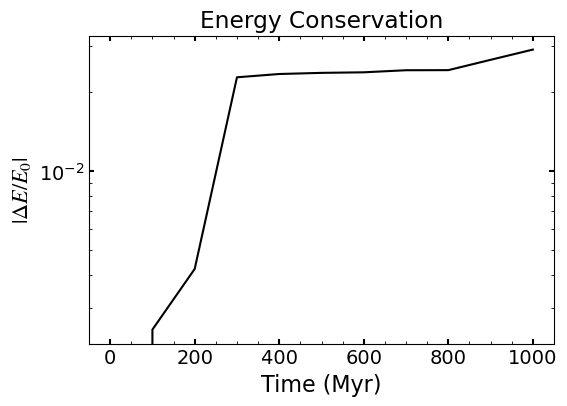

<Figure size 640x480 with 0 Axes>

(-60.0, 60.0)

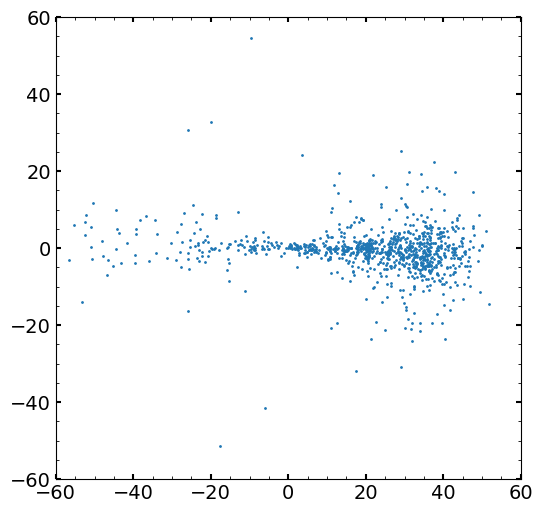

In [38]:
plt.figure(figsize=(6, 6))
plt.scatter(shell.x(-1), shell.y(-1), s=1)
plt.xlim(-60, 60)
plt.ylim(-60, 60)

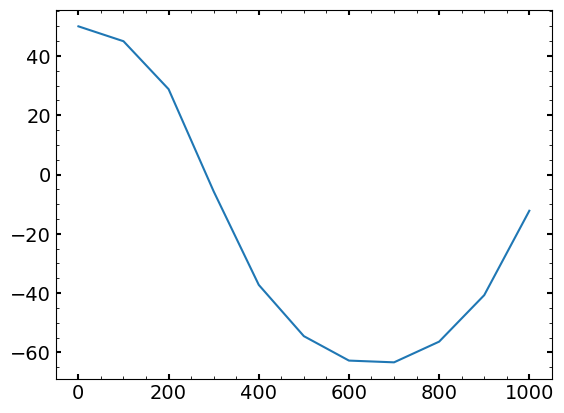

In [39]:
plt.plot(prog.times, prog.x())

In [41]:
np.hstack((prog.pos(-1), prog.vel(-1)))

array([[-1.22285580e+01, -1.98991986e-01,  2.23604966e-01,
         3.85935257e-01,  4.21370647e-03, -5.01470393e-03]])

In [51]:
def calculate_bound(pos, vel, self_pot, center_pos, center_vel):
    '''
    Determine which stars are bound through iterative 
    calculation.
    '''
    f_xv = np.hstack((pos, vel))
    f_center = np.hstack((center_pos, center_vel))
    Rmax = 10.0
    use  = np.sum((pos - center_pos)**2, axis=1) < Rmax**2
    # iteratively refine the selection, retaining only bound particles (which have
    # negative total energy in the satellite-centered frame using its own potential only)
    prev_f_center = f_center
    for i in range(10):
        f_center = np.median(f_xv[use], axis=0)
        f_bound = self_pot + 0.5 * mass* np.sum((f_xv[:,3:6] - f_center[3:6])**2, axis=1) < 0
        if np.sum(f_bound)<=1 or all(f_center==prev_f_center): break
        use = f_bound * (np.sum((f_xv[:,0:3] - f_center[0:3])**2, axis=1) < Rmax**2)
    return f_bound

In [58]:
shell.pos(i)

array([[52.01303248,  1.95227313,  0.89356752],
       [49.49511273, -0.10331492,  0.96694439],
       [49.66509302, -0.12466067, -0.50073388],
       ...,
       [49.45101171,  2.0083471 ,  1.76172831],
       [50.03323729,  0.24635621,  0.41840357],
       [50.07933457,  0.92168769,  2.92278648]], shape=(1000, 3))

In [60]:
mask = []
for i, t in enumerate(shell.times):
    mask.append(calculate_bound(shell.pos(i), shell.vel(i), shell.self_PE(i), prog.pos(i)[0], prog.vel(i)[0]))
    print(f'{np.sum(mask[i])} bound particles at time {t:.1f}')

1000 bound particles at time 0.0
970 bound particles at time 100.0
924 bound particles at time 200.0
408 bound particles at time 300.0
460 bound particles at time 400.0
455 bound particles at time 500.0
424 bound particles at time 600.0
297 bound particles at time 700.0
129 bound particles at time 800.0
12 bound particles at time 900.0
/Users/gabrielpfaffman/miniconda3/lib/python3.13/site-packages/numpy/_core/fromnumeric.py:3860: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,

/Users/gabrielpfaffman/miniconda3/lib/python3.13/site-packages/numpy/_core/_methods.py:136: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(

0 bound particles at time 1000.0


In [70]:
np.save('bound_mask.npy', mask)

In [ ]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig, ax = plt.subplots(figsize=(6, 6))

def animate(i):
    ax.clear()
    ax.scatter(shell.x(i)[~mask[i]], shell.y(i)[~mask[i]], s=2, c='k', alpha=0.25, label='unbound')
    ax.scatter(shell.x(i)[mask[i]], shell.y(i)[mask[i]], s=1, c='k', label='bound')
    ax.set_xlim(-60, 60)
    ax.set_ylim(-60, 60)
    ax.set_xlabel('x [kpc]')
    ax.set_ylabel('y [kpc]')
    ax.set_title(f't = {shell.times[i]:.0f} Myr')
    ax.legend(loc='upper right')

anim = FuncAnimation(fig, animate, frames=len(shell.times), interval=500)
plt.close(fig)
HTML(anim.to_jshtml())